In [1]:
import sys
!{sys.executable} -m pip install -r requirements.txt

In [2]:
import torch
import numpy as np
import pandas as pd
import cv2
import shapely

print("All packages loaded successfully")
print("Torch version:", torch.__version__)

All packages loaded successfully
Torch version: 2.8.0


In [4]:
import sys
!{sys.executable} model/OOD_supervised_contrastive_classifier.py

Loading OOD data...

Using environment column for per environment analysis: disaster

Split sizes:
split
OOD_train    166544
OOD_hold      53403
OOD_test      46833
Name: count, dtype: int64

Train label distribution:
damage_label
no-damage       120576
major-damage     17327
minor-damage     17063
destroyed        11578
Name: count, dtype: int64

OOD validation label distribution:
damage_label
no-damage       37859
destroyed        6089
major-damage     2260
minor-damage      625
Name: count, dtype: int64

OOD hold label distribution:
damage_label
no-damage       38388
minor-damage     8428
destroyed        3558
major-damage     3029
Name: count, dtype: int64

Train environments:
['hurricane-harvey', 'hurricane-matthew', 'mexico-earthquake', 'palu-tsunami']

OOD validation environments:
['guatemala-volcano', 'hurricane-florence', 'midwest-flooding', 'santa-rosa-wildfire']

OOD hold environments:
['hurricane-michael', 'socal-fire']

Image overlap check:
OOD_train intersection OOD_val: 

# Model Performance Analysis and Interpretation

## 1. Training Dynamics

The training process shows stable behavior and no clear evidence of severe overfitting.

During the supervised contrastive pretraining stage, the contrastive loss decreases steadily from 3.9255 to 3.7599. This suggests that the encoder is learning a more structured representation space.

During the classifier training stage, training loss decreases from 0.5962 to 0.5353, while OOD test performance remains strong:

* Test Macro F1 ranges between 0.4298 and 0.4551
* Best performance is reached at epoch 5 with a Macro F1 of 0.4551

This suggests that:

* the contrastive encoder learns useful representations
* classifier training remains stable
* removing class weights improves calibration
* label smoothing helps reduce overly confident predictions

---

## 2. Overall Performance

The final performance of the model is:

| Split | Macro F1 |
| ----- | -------- |
| Test  | 0.4551   |
| Hold  | 0.4014   |

Key observations:

* performance improves substantially compared to the previous contrastive version
* the holdout score remains strong, although lower than the test score
* the model generalizes better than the baseline under OOD conditions
* the drop from test to hold indicates that unseen disaster locations still introduce meaningful distribution shift

---

## 3. Class-wise Performance

The model shows strong variation across classes.

### No damage

* Test F1: 0.8109  
* Hold F1: 0.8111  

Performance is high and highly stable across splits.

This indicates that the model learns robust features for identifying undamaged buildings across unseen locations.

---

### Minor damage

* Test F1: 0.0453  
* Hold F1: 0.3064  

Performance is very low on the test split but substantially higher on the holdout split.

This difference is strongly influenced by class distribution:

* minor damage is heavily underrepresented in the test split
* minor damage is much more represented in the hold split
* subtle damage remains difficult to identify reliably

---

### Major damage

* Test F1: 0.1756  
* Hold F1: 0.1857  

Performance is low but consistent across splits.

This suggests that major damage remains one of the most difficult classes, likely because it overlaps visually with both minor damage and destroyed buildings.

---

### Destroyed

* Test F1: 0.7889  
* Hold F1: 0.3023  

Performance is very strong on the test split but drops considerably on the hold split.

This suggests that the model learns strong features for destroyed buildings in some disaster contexts, but these features do not fully transfer across all unseen locations.

---

## 4. Precision Recall Trade-off

Compared to the previous contrastive model with class weights, the new model shows a better precision recall balance.

The model still over-predicts some damage classes, especially minor and major damage, but the over-prediction is less extreme than before.

For example, on the test split:

* minor-damage true count: 625
* minor-damage predicted count: 3043
* major-damage true count: 2260
* major-damage predicted count: 9121

This indicates that:

* the model remains sensitive to damage
* false positives are still present
* removing class weights reduced excessive minority-class prediction
* label smoothing improved prediction calibration

---

## 5. Effect of Removing Class Weights

In this version, class weights were removed and label smoothing was added.

This change was important because the previous contrastive model combined two mechanisms that both emphasized minority classes:

* supervised contrastive learning
* class-weighted cross entropy

This created an overcorrection, causing the model to predict damage classes too aggressively.

After removing class weights:

### Positive effects

* Test Macro F1 improved from 0.3686 to 0.4551
* Hold Macro F1 improved from 0.3662 to 0.4014
* prediction distributions became less extreme
* no-damage performance became much stronger and more stable
* overall calibration improved

### Remaining limitations

* minor and major damage still have low precision
* damage severity levels remain difficult to separate
* the model still shows some tendency to over-predict damage

---

## 6. Generalization to Holdout Data

The model achieves:

* Test Macro F1: 0.4551
* Hold Macro F1: 0.4014

The holdout performance is lower than the test performance, but remains substantially improved compared to the previous contrastive run.

This suggests that:

* contrastive representation learning improves OOD generalization
* the learned representations transfer reasonably well to unseen disaster locations
* distribution shift remains present, especially for destroyed and subtle damage classes

The performance gap between test and hold indicates that the hold split contains visual or label-distribution patterns that remain more difficult for the model.

---

## 7. Limitations

The experiment highlights several limitations:

* minor damage remains difficult to classify
* major damage remains visually ambiguous
* destroyed buildings generalize unevenly across locations
* test and hold splits have different class distributions
* the model still over-predicts some damage categories
* representation learning improves robustness but does not fully solve OOD generalization

These limitations suggest that the remaining errors are driven by both:

* visual ambiguity between damage levels
* distribution differences across disaster locations

---

## Final Interpretation

The revised supervised contrastive model provides the strongest representation-learning result so far.

Removing class weights and adding label smoothing substantially improved performance and reduced excessive damage over-prediction.

Overall:

* Test Macro F1 increased to 0.4551
* Hold Macro F1 increased to 0.4014
* no-damage classification became highly stable
* minor and major damage remain the most challenging classes
* contrastive learning improves OOD robustness, but class-level robustness remains uneven

This supports the interpretation that supervised contrastive learning improves the learned representation space and provides better generalization to unseen disaster locations, especially when not combined with overly aggressive class weighting.


Loaded rows: 267015

Seeds loaded:
[42, 123, 999, 2024, 2025]

Rows per seed:
seed
42      53403
123     53403
999     53403
2024    53403
2025    53403
Name: count, dtype: int64

Pooled normalized confusion matrix:

              no-damage  minor-damage  major-damage  destroyed
no-damage         0.816         0.122         0.047      0.015
minor-damage      0.595         0.275         0.102      0.028
major-damage      0.465         0.278         0.190      0.067
destroyed         0.299         0.302         0.210      0.189


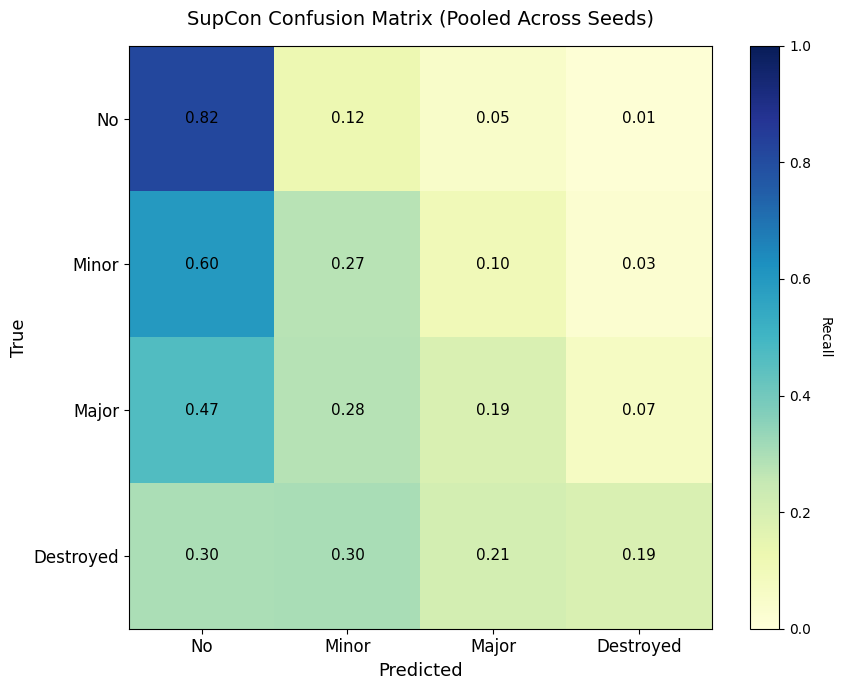

In [23]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

# ============================================================
# Configuration
# ============================================================

SEEDS = [42, 123, 999, 2024, 2025]

labels = [
    "no-damage",
    "minor-damage",
    "major-damage",
    "destroyed",
]

short_labels = [
    "No",
    "Minor",
    "Major",
    "Destroyed",
]

BASE_DIR = (
    Path.home()
    / "Desktop"
    / "OOD_training_outputs"
    / "resnet50_supervised_contrastive_unweighted_5seeds_1se"
)

# ============================================================
# Load all seed prediction files
# ============================================================

dfs = []

for seed in SEEDS:

    pred_path = (
        BASE_DIR
        / f"seed_{seed}"
        / "ood_hold_predictions_selected_1se.csv"
    )

    if not pred_path.exists():
        raise FileNotFoundError(
            f"Missing prediction file: {pred_path}"
        )

    df_seed = pd.read_csv(pred_path)

    df_seed["seed"] = seed

    dfs.append(df_seed)

# ============================================================
# Concatenate all predictions
# ============================================================

df = pd.concat(dfs, ignore_index=True)

print("\nLoaded rows:", len(df))

print("\nSeeds loaded:")
print(sorted(df["seed"].unique()))

print("\nRows per seed:")
print(df["seed"].value_counts().sort_index())

# ============================================================
# True / predicted labels
# ============================================================

y_true = df["target_id"]
y_pred = df["pred_id"]

# ============================================================
# Overall pooled confusion matrix
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3],
)

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

print("\nPooled normalized confusion matrix:\n")

print(
    pd.DataFrame(
        cm_norm,
        index=labels,
        columns=labels,
    ).round(3)
)

# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(
    cm_norm,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
)

# ============================================================
# Colorbar
# ============================================================

cbar = fig.colorbar(im, ax=ax)

cbar.ax.set_ylabel(
    "Recall",
    rotation=270,
    labelpad=15,
)

# ============================================================
# Axis labels
# ============================================================

ax.set_xticks(np.arange(len(short_labels)))
ax.set_yticks(np.arange(len(short_labels)))

ax.set_xticklabels(
    short_labels,
    fontsize=12,
)

ax.set_yticklabels(
    short_labels,
    fontsize=12,
)

ax.set_xlabel(
    "Predicted",
    fontsize=13,
)

ax.set_ylabel(
    "True",
    fontsize=13,
)

ax.set_title(
    "SupCon Confusion Matrix (Pooled Across Seeds)",
    fontsize=14,
    pad=15,
)

# ============================================================
# Cell annotations
# ============================================================

for i in range(cm_norm.shape[0]):

    for j in range(cm_norm.shape[1]):

        ax.text(
            j,
            i,
            f"{cm_norm[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=11,
            color="black",
        )

# ============================================================
# Final layout
# ============================================================

plt.tight_layout()
plt.show()

In [24]:
from pathlib import Path
import pandas as pd

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
)

# ============================================================
# Configuration
# ============================================================

SEEDS = [42, 123, 999, 2024, 2025]

DISASTER_NAME = "hurricane-michael"

BASE_DIR = (
    Path.home()
    / "Desktop"
    / "OOD_training_outputs"
    / "resnet50_supervised_contrastive_unweighted_5seeds_1se"
)

# ============================================================
# Load all seeds
# ============================================================

dfs = []

for seed in SEEDS:

    pred_path = (
        BASE_DIR
        / f"seed_{seed}"
        / "ood_hold_predictions_selected_1se.csv"
    )

    if not pred_path.exists():
        raise FileNotFoundError(
            f"Missing prediction file: {pred_path}"
        )

    df_seed = pd.read_csv(pred_path)

    df_seed["seed"] = seed

    dfs.append(df_seed)

# ============================================================
# Concatenate
# ============================================================

df = pd.concat(dfs, ignore_index=True)

print("\nLoaded rows:", len(df))

# ============================================================
# Filter disaster
# ============================================================

subset = df[df["disaster"] == DISASTER_NAME].copy()

print(f"\nSamples in {DISASTER_NAME}: {len(subset)}")

# ============================================================
# Macro F1
# ============================================================

macro_f1 = f1_score(
    subset["target_id"],
    subset["pred_id"],
    average="macro",
)

print(f"\nMacro F1 ({DISASTER_NAME}): {macro_f1:.4f}")

# ============================================================
# Classification report
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        subset["target_id"],
        subset["pred_id"],
        digits=4,
        zero_division=0,
    )
)

# ============================================================
# Confusion matrix
# ============================================================

cm = confusion_matrix(
    subset["target_id"],
    subset["pred_id"],
    normalize="true",
)

print("\nNormalized Confusion Matrix:\n")

print(cm)


Loaded rows: 267015

Samples in hurricane-michael: 175635

Macro F1 (hurricane-michael): 0.3808

Classification Report:

              precision    recall  f1-score   support

           0     0.7277    0.7727    0.7496    113455
           1     0.3203    0.2768    0.2970     41460
           2     0.2072    0.1869    0.1965     14595
           3     0.2792    0.2808    0.2800      6125

    accuracy                         0.5898    175635
   macro avg     0.3836    0.3793    0.3808    175635
weighted avg     0.5726    0.5898    0.5804    175635


Normalized Confusion Matrix:

[[0.77272046 0.1615266  0.04539245 0.0203605 ]
 [0.59249879 0.27684515 0.10299083 0.02766522]
 [0.46817403 0.27756081 0.18691333 0.06735183]
 [0.22873469 0.32408163 0.16636735 0.28081633]]


In [26]:
from pathlib import Path
import pandas as pd

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
)

# ============================================================
# Configuration
# ============================================================

SEEDS = [42, 123, 999, 2024, 2025]

DISASTER_NAME = "hurricane-florence"

BASE_DIR = (
    Path.home()
    / "Desktop"
    / "OOD_training_outputs"
    / "resnet50_supervised_contrastive_unweighted_5seeds_1se"
)

class_names = [
    "no-damage",
    "minor-damage",
    "major-damage",
    "destroyed",
]

# ============================================================
# Load OOD validation predictions across all seeds
# Florence is in OOD_test -> validation predictions
# ============================================================

dfs = []

for seed in SEEDS:

    pred_path = (
        BASE_DIR
        / f"seed_{seed}"
        / "ood_val_predictions_selected_1se.csv"
    )

    if not pred_path.exists():
        raise FileNotFoundError(
            f"Missing prediction file: {pred_path}"
        )

    df_seed = pd.read_csv(pred_path)
    df_seed["seed"] = seed

    dfs.append(df_seed)

df = pd.concat(dfs, ignore_index=True)

print("\nLoaded rows:", len(df))

print("\nSeeds loaded:")
print(sorted(df["seed"].unique()))

print("\nAvailable disaster names:")
print(sorted(df["disaster"].astype(str).unique()))

# ============================================================
# Filter Florence
# ============================================================

subset = df[
    df["disaster"]
    .astype(str)
    .str.strip()
    .str.lower()
    == DISASTER_NAME.lower()
].copy()

print(f"\nSamples in {DISASTER_NAME}: {len(subset)}")

if len(subset) == 0:
    raise ValueError(
        f"No samples found for disaster: {DISASTER_NAME}"
    )

# ============================================================
# Macro F1
# ============================================================

macro_f1 = f1_score(
    subset["target_id"],
    subset["pred_id"],
    average="macro",
    labels=[0, 1, 2, 3],
    zero_division=0,
)

print(f"\nPooled Macro F1 ({DISASTER_NAME}): {macro_f1:.4f}")

# ============================================================
# Classification report
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        subset["target_id"],
        subset["pred_id"],
        labels=[0, 1, 2, 3],
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

# ============================================================
# Normalized confusion matrix
# ============================================================

cm = confusion_matrix(
    subset["target_id"],
    subset["pred_id"],
    labels=[0, 1, 2, 3],
    normalize="true",
)

print("\nNormalized Confusion Matrix:\n")
print(cm)

# ============================================================
# Pretty DataFrame version
# ============================================================

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names,
)

print("\nConfusion Matrix DataFrame:\n")
print(cm_df.round(3))


Loaded rows: 234165

Seeds loaded:
[42, 123, 999, 2024, 2025]

Available disaster names:
['guatemala-volcano', 'hurricane-florence', 'midwest-flooding', 'santa-rosa-wildfire']

Samples in hurricane-florence: 53640

Pooled Macro F1 (hurricane-florence): 0.3052

Classification Report:

              precision    recall  f1-score   support

   no-damage     0.8703    0.6018    0.7116     42330
minor-damage     0.0226    0.1707    0.0399      1160
major-damage     0.3525    0.5221    0.4208      9745
   destroyed     0.0327    0.0938    0.0485       405

    accuracy                         0.5742     53640
   macro avg     0.3195    0.3471    0.3052     53640
weighted avg     0.7516    0.5742    0.6393     53640


Normalized Confusion Matrix:

[[0.60184266 0.17224191 0.20621309 0.01970234]
 [0.45689655 0.17068966 0.34913793 0.02327586]
 [0.32478194 0.12621857 0.5221139  0.02688558]
 [0.24691358 0.13333333 0.52592593 0.09382716]]

Confusion Matrix DataFrame:

              no-damage  mino

Available splits:
split
OOD_train    166544
OOD_hold      53403
OOD_test      46833
Name: count, dtype: int64

Rows in selected split: 53403
Rows in prediction file: 53403

Number of available images: 1191

First available image IDs:
image_id
hurricane-michael_00000470    261
socal-fire_00000806           243
hurricane-michael_00000513    236
socal-fire_00000902           232
hurricane-michael_00000527    230
Name: count, dtype: int64

Selected image_id: hurricane-michael_00000003
Number of buildings in selected image: 35


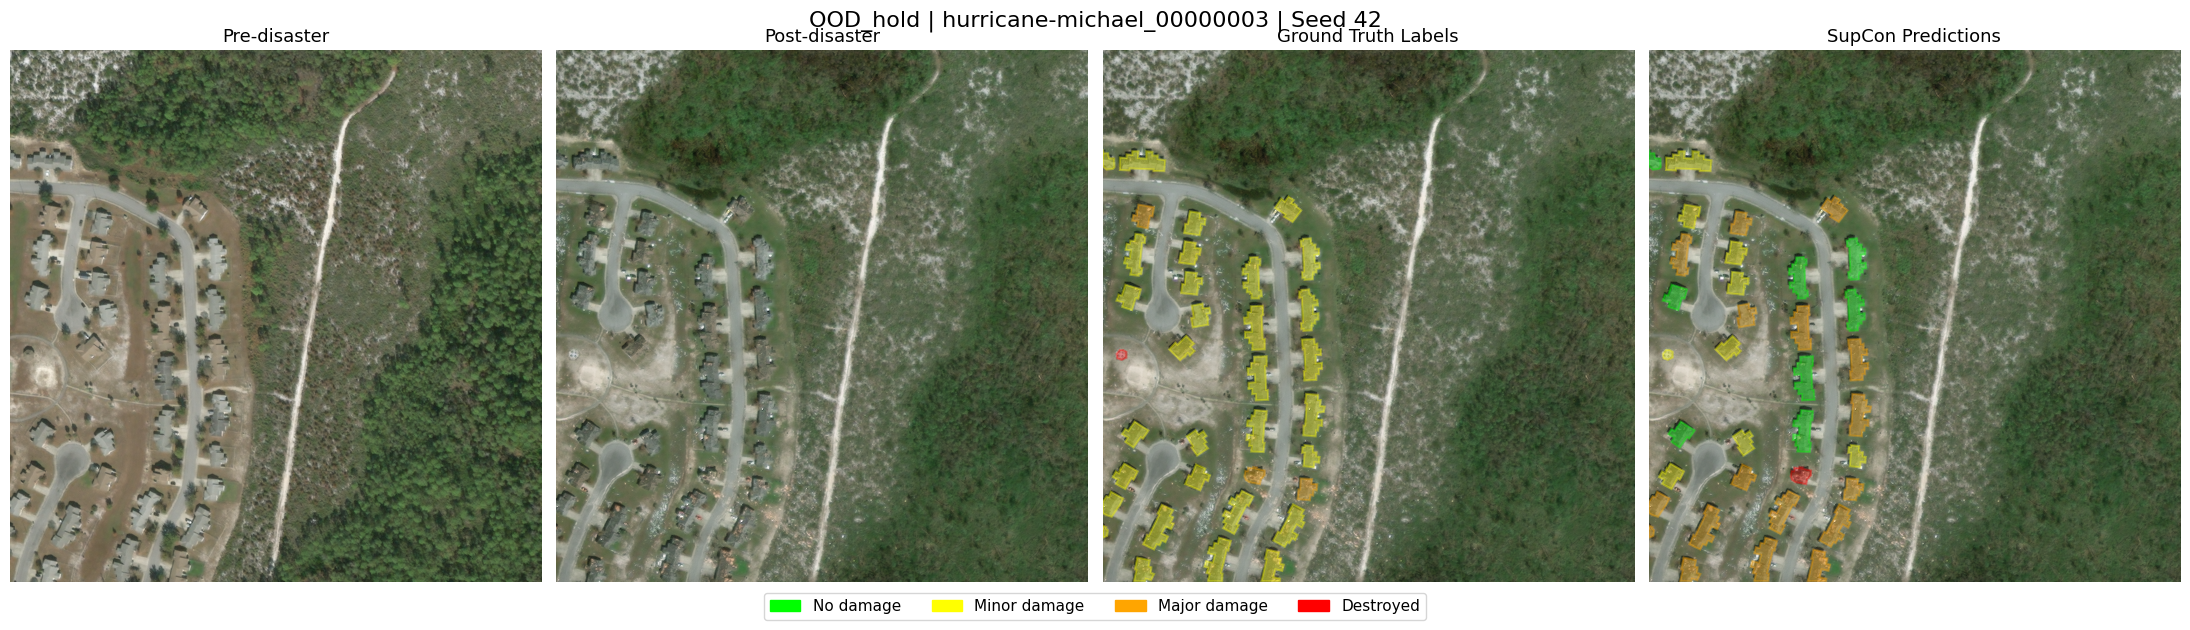

In [19]:
from pathlib import Path

import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely import wkt

# =========================
# Configuration
# =========================

SEED = 42
CSV_SPLIT = "OOD_hold"

BASE_DIR = Path.home() / "Desktop"

CSV_PATH = (
    BASE_DIR
    / "OOD_processed"
    / "buildings_all_OOD_with_crops.csv"
)

OUTPUT_DIR = (
    BASE_DIR
    / "OOD_training_outputs"
    / "resnet50_supervised_contrastive_unweighted_5seeds_1se"
)

PRED_PATH = (
    OUTPUT_DIR
    / f"seed_{SEED}"
    / "ood_hold_predictions_selected_1se.csv"
)

LABELS = [
    "no-damage",
    "minor-damage",
    "major-damage",
    "destroyed",
]

COLORS = {
    "no-damage": "lime",
    "minor-damage": "yellow",
    "major-damage": "orange",
    "destroyed": "red",
}

# =========================
# Load data
# =========================

df = pd.read_csv(CSV_PATH)
pred_df = pd.read_csv(PRED_PATH)

print("Available splits:")
print(df["split"].value_counts())

split_df = df[df["split"] == CSV_SPLIT].copy().reset_index(drop=True)

print("\nRows in selected split:", len(split_df))
print("Rows in prediction file:", len(pred_df))

if len(split_df) == 0:
    raise ValueError(f"No rows found for split: {CSV_SPLIT}")

if len(split_df) != len(pred_df):
    raise ValueError(
        f"Mismatch: CSV split has {len(split_df)} rows, "
        f"but prediction file has {len(pred_df)} rows."
    )

# =========================
# Add predictions
# =========================

split_df["pred_idx"] = pred_df["pred_id"].values
split_df["true_idx"] = pred_df["target_id"].values

split_df["pred_label"] = split_df["pred_idx"].map(lambda i: LABELS[int(i)])
split_df["true_label"] = split_df["true_idx"].map(lambda i: LABELS[int(i)])

# =========================
# Select image
# =========================

counts = split_df["image_id"].value_counts()

print("\nNumber of available images:", len(counts))
print("\nFirst available image IDs:")
print(counts.head())

IMAGE_INDEX = 520

if IMAGE_INDEX >= len(counts):
    raise ValueError(
        f"IMAGE_INDEX={IMAGE_INDEX} is too large. "
        f"Maximum valid index is {len(counts) - 1}."
    )

image_id = counts.index[IMAGE_INDEX]
img_df = split_df[split_df["image_id"] == image_id].copy()

print("\nSelected image_id:", image_id)
print("Number of buildings in selected image:", len(img_df))

# =========================
# Load images
# =========================

pre_path = Path(img_df.iloc[0]["pre_image_path"])
post_path = Path(img_df.iloc[0]["post_image_path"])

if not pre_path.exists():
    raise FileNotFoundError(f"Missing pre-disaster image: {pre_path}")

if not post_path.exists():
    raise FileNotFoundError(f"Missing post-disaster image: {post_path}")

pre = np.array(Image.open(pre_path))
post = np.array(Image.open(post_path))

# =========================
# Plotting helper
# =========================

def draw_polygons(ax, image, rows, label_col, title):
    ax.imshow(image)
    ax.set_title(title, fontsize=13)
    ax.axis("off")

    for _, row in rows.iterrows():
        poly = wkt.loads(row["wkt"])
        label = row[label_col]
        color = COLORS[label]

        x, y = poly.exterior.xy
        coords = list(zip(x, y))

        patch = mpatches.Polygon(
            coords,
            closed=True,
            fill=True,
            alpha=0.35,
            edgecolor=color,
            facecolor=color,
            linewidth=1.5,
        )

        ax.add_patch(patch)

# =========================
# Legend
# =========================

legend_elements = [
    mpatches.Patch(color=COLORS["no-damage"], label="No damage"),
    mpatches.Patch(color=COLORS["minor-damage"], label="Minor damage"),
    mpatches.Patch(color=COLORS["major-damage"], label="Major damage"),
    mpatches.Patch(color=COLORS["destroyed"], label="Destroyed"),
]

# =========================
# Plot
# =========================

fig, axes = plt.subplots(1, 4, figsize=(22, 6))

axes[0].imshow(pre)
axes[0].set_title("Pre-disaster", fontsize=13)
axes[0].axis("off")

axes[1].imshow(post)
axes[1].set_title("Post-disaster", fontsize=13)
axes[1].axis("off")

draw_polygons(
    axes[2],
    post,
    img_df,
    label_col="true_label",
    title="Ground Truth Labels",
)

draw_polygons(
    axes[3],
    post,
    img_df,
    label_col="pred_label",
    title="SupCon Predictions",
)

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.05),
    fontsize=11,
)

plt.suptitle(
    f"{CSV_SPLIT} | {image_id} | Seed {SEED}",
    fontsize=16,
)

plt.tight_layout()
plt.show()

In [12]:
from pathlib import Path

OUTPUT_DIR = Path.home() / "Desktop" / "OOD_training_outputs" / "resnet50_supervised_contrastive"

print(OUTPUT_DIR.exists())
print(list(OUTPUT_DIR.glob("*")))

True
[PosixPath('/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/summary.json'), PosixPath('/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/ood_hold_targets.npy'), PosixPath('/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/ood_hold_preds.npy'), PosixPath('/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/contrastive_latest.pt'), PosixPath('/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/ood_hold_confusion_matrix.npy'), PosixPath('/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/best_model.pt'), PosixPath('/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/contrastive_final.pt'), PosixPath('/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/contrastive_history.csv'), PosixPath('/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/ood_test_preds.npy'), PosixPath('/Users/p